# 1. Introducción y Generación del Escenario
Como vimos en la lectura, los datos reales vienen sucios. Vamos a simular un dataset financiero con errores típicos.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de semilla para reproducibilidad
np.random.seed(42)

# Generación de un dataset "Sucio" (1000 filas)
data = {
    'ingreso': np.random.normal(50000, 15000, 1000),
    'edad': np.random.randint(18, 70, 1000),
    'deuda': np.random.normal(5000, 2000, 1000),
    'score_credito': np.random.randint(300, 850, 1000),
    'transacciones_mes': np.random.poisson(20, 1000),
    'variable_inutil': 1, # Varianza cero (mencionado en PDF 3)
    'riesgo_default': np.random.randint(0, 2, 1000) # Target
}

df = pd.DataFrame(data)

# --- INYECCIÓN DE ERRORES (Basado en PDF 3) ---
# 1. Valores Faltantes (Missing Values)
df.loc[np.random.choice(df.index, 50), 'ingreso'] = np.nan
df.loc[np.random.choice(df.index, 30), 'score_credito'] = np.nan

# 2. Outliers extremos (PDF 3 pág 1)
df.loc[0, 'ingreso'] = 10000000 # Un millonario atípico
df.loc[1, 'edad'] = 150 # Error de digitación

# 3. Duplicados (PDF 3 pág 3)
df = pd.concat([df, df.iloc[:20]], ignore_index=True)

print(f"Dataset inicial cargado: {df.shape}")
df.head()

Dataset inicial cargado: (1020, 7)


,ingreso,edad,deuda,score_credito,transacciones_mes,variable_inutil,riesgo_default
0,1.000000e+07,61,4731.965667,668.0,19,1,0
1,4.792604e+04,150,5029.376389,848.0,12,1,0
2,5.971533e+04,57,3430.203374,486.0,19,1,0
3,7.284545e+04,28,6296.560868,744.0,15,1,0
4,4.648770e+04,20,4758.103703,662.0,21,1,0


# 2. Limpieza Básica y Duplicados
Detectar y eliminar duplicados y columnas de varianza cero.

In [3]:
# Verificar duplicados
duplicados = df.duplicated().sum()
print(f"Filas duplicadas detectadas: {duplicados}")

# Eliminar duplicados
df_clean = df.drop_duplicates()

# Verificar columnas de varianza cero (PDF 3, pág 2)
# "Las columnas que tienen un valor único... probablemente sean inútiles"
for col in df_clean.columns:
    if df_clean[col].nunique() == 1:
        print(f"Eliminando columna de varianza cero: {col}")
        df_clean = df_clean.drop(columns=[col])

print(f"Dimensiones post-limpieza básica: {df_clean.shape}")

Filas duplicadas detectadas: 20
Eliminando columna de varianza cero: variable_inutil
Dimensiones post-limpieza básica: (1000, 6)


# 3. Tratamiento de Valores Faltantes
Analizar nulos y decidir estrategia.


In [4]:
# Ver nulos
print(df_clean.isnull().sum())

# Estrategia: Imputación por Mediana (más robusta a outliers que la media)
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
# Solo imputamos columnas numéricas con faltantes
cols_missing = ['ingreso', 'score_credito']
df_clean[cols_missing] = imputer.fit_transform(df_clean[cols_missing])

print("Nulos restantes:", df_clean.isnull().sum().sum())

ingreso              47
edad                  0
deuda                 0
score_credito        30
transacciones_mes     0
riesgo_default        0
dtype: int64
Nulos restantes: 0


# 4. Detección de Outliers: Método IQR
Crear una función para detectar outliers y visualizarlos.

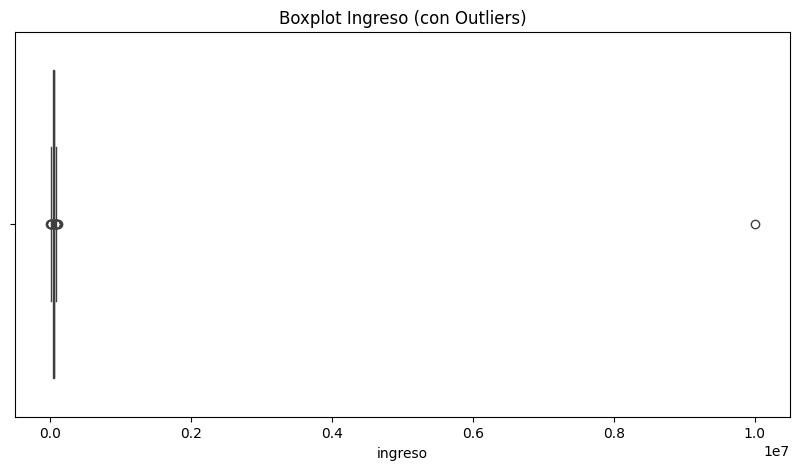

Outliers detectados en Ingreso: 13
Rango aceptable: 13258.670641285615 a 87000.81529979654


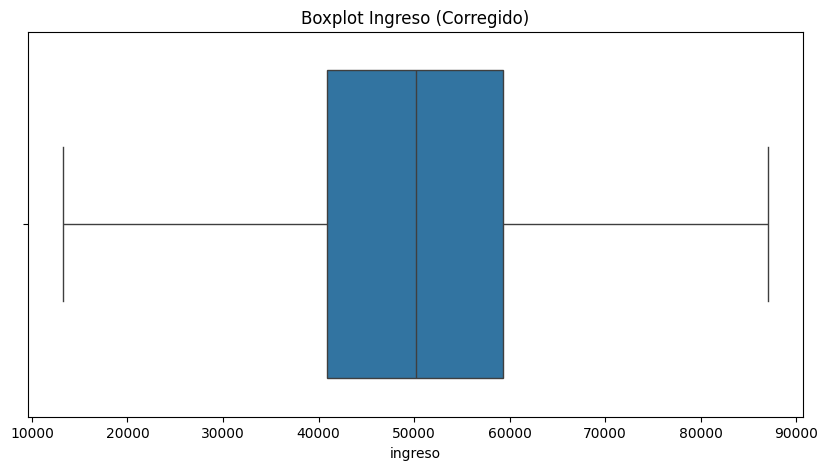

In [5]:
def detectar_outliers_iqr(dataframe, columna):
    Q1 = dataframe[columna].quantile(0.25)
    Q3 = dataframe[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = dataframe[(dataframe[columna] < limite_inferior) | (dataframe[columna] > limite_superior)]
    return outliers, limite_inferior, limite_superior

# Visualización antes de tratar
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_clean['ingreso'])
plt.title("Boxplot Ingreso (con Outliers)")
plt.show()

# Detectar
outliers_ingreso, li, ls = detectar_outliers_iqr(df_clean, 'ingreso')
print(f"Outliers detectados en Ingreso: {len(outliers_ingreso)}")
print(f"Rango aceptable: {li} a {ls}")

# Tratamiento: Clipping (tope) en lugar de eliminar (Opcional, pero recomendado en industria)
df_clean['ingreso'] = df_clean['ingreso'].clip(lower=li, upper=ls)

# Visualización post-tratamiento
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_clean['ingreso'])
plt.title("Boxplot Ingreso (Corregido)")
plt.show()

# Prevención de Fugas y Pipelines

# 1. El Problema: Enfoque Ingenuo (Naive)
Normalizar TODO el dataset antes de dividir (Error grave).


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Separar X e y
X = df_clean.drop('riesgo_default', axis=1)
y = df_clean['riesgo_default']

# --- ENFOQUE INCORRECTO (Data Leakage) ---
# 1. Normalizar TODO primero
scaler_naive = MinMaxScaler()
X_naive = scaler_naive.fit_transform(X) # ¡ERROR! El scaler ve datos de test

# 2. Luego dividir
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_naive, y, test_size=0.3, random_state=42)

# 3. Entrenar y Evaluar
model_n = LogisticRegression()
model_n.fit(X_train_n, y_train_n)
y_pred_n = model_n.predict(X_test_n)
acc_n = accuracy_score(y_test_n, y_pred_n)

print(f"Precisión (Enfoque Ingenuo/Con Fuga): {acc_n:.4f}")
print("Alerta: Este resultado está contaminado porque el Scaler conocía el rango de Test.")

Precisión (Enfoque Ingenuo/Con Fuga): 0.5000
Alerta: Este resultado está contaminado porque el Scaler conocía el rango de Test.


# 2. La Solución: Enfoque Correcto con Split Manual
Preparación de datos debe realizarse únicamente en el conjunto de entrenamiento

In [7]:
# --- ENFOQUE CORRECTO (Manual) ---
# 1. Primero dividir
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Definir scaler y ajustar SOLO en Train
scaler_correct = MinMaxScaler()
scaler_correct.fit(X_train) # El scaler aprende min/max solo de train

# 3. Transformar ambos
X_train_scaled = scaler_correct.transform(X_train)
X_test_scaled = scaler_correct.transform(X_test) # Usamos las reglas de train para test

# 4. Entrenar y Evaluar
model_c = LogisticRegression()
model_c.fit(X_train_scaled, y_train)
y_pred_c = model_c.predict(X_test_scaled)
acc_c = accuracy_score(y_test, y_pred_c)

print(f"Precisión (Enfoque Correcto/Sin Fuga): {acc_c:.4f}")

Precisión (Enfoque Correcto/Sin Fuga): 0.5000


# 3. Automatización Profesional: Scikit-Learn Pipelines
Empaquetar todo para evitar errores humanos y usar Cross-Validation

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold

# Definir los pasos del Pipeline
# Paso 1: Scaler
# Paso 2: Modelo
pasos = [
    ('scaler', MinMaxScaler()),
    ('model', LogisticRegression())
]

pipeline = Pipeline(steps=pasos)

# Configuración de Validación Cruzada (K-Fold)
# Como indica el PDF 1 pág 4: RepeatedStratifiedKFold
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

# Evaluar el pipeline completo
# El pipeline se encarga de hacer fit del scaler SOLO en los folds de entrenamiento internamente
scores = cross_val_score(pipeline, X, y, scoring='accuracy', cv=cv, n_jobs=-1)

print(f"Precisión Promedio (Pipeline + CV): {np.mean(scores):.4f}")
print(f"Desviación Estándar: {np.std(scores):.4f}")

Precisión Promedio (Pipeline + CV): 0.4967
Desviación Estándar: 0.0459
